# Bayesian Black-Box Optimisation (BBO) — Capstone Project, Submission 1

**Imperial Business School — Executive Master in ML/AI**  
**Author:** Gian Franco  
**Date:** March 2026

---

## Objective

For each of **8 unknown black-box functions**, propose a **new query point** that **maximises** the expected output using:
- **Gaussian Process (GP)** surrogate models with Matérn 5/2 kernel
- **Expected Improvement (EI)** acquisition function
- Multi-start L-BFGS-B optimisation of the acquisition surface

All inputs must lie in **[0, 1)**, i.e. `[0.000000, 0.999999]`, and are submitted as `x1-x2-x3-...-xn` with exactly 6 decimal places.

---


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print("All imports successful.")


All imports successful.


In [8]:
import os
print(os.getcwd())  # Deve mostrare la cartella che contiene initial_data/

C:\Users\gianfranco.cattaneo\Downloads


## 1. Load and Inspect Initial Data

Each function provides `initial_inputs.npy` (X) and `initial_outputs.npy` (Y). Key properties:
- **Functions 1–2:** 2D input, 10 initial points
- **Function 3:** 3D input, 15 initial points
- **Functions 4–5:** 4D input, 30 and 20 initial points respectively
- **Function 6:** 5D input, 20 initial points
- **Function 7:** 6D input, 30 initial points
- **Function 8:** 8D input, 40 initial points

The dimensionality and point count scale together, which is consistent with a budget proportional to the curse of dimensionality.


In [9]:
BASE_DIR = "initial_data"  # Adjust path if needed

data = {}
for i in range(1, 9):
    X = np.load(f"{BASE_DIR}/function_{i}/initial_inputs.npy")
    Y = np.load(f"{BASE_DIR}/function_{i}/initial_outputs.npy")
    data[i] = {'X': X, 'Y': Y}
    print(f"Function {i}: X={X.shape}, Y={Y.shape}, "
          f"Y_range=[{Y.min():.6f}, {Y.max():.6f}], "
          f"Best_Y={Y.max():.6f}")


Function 1: X=(10, 2), Y=(10,), Y_range=[-0.003606, 0.000000], Best_Y=0.000000
Function 2: X=(10, 2), Y=(10,), Y_range=[-0.065624, 0.611205], Best_Y=0.611205
Function 3: X=(15, 3), Y=(15,), Y_range=[-0.398926, -0.034835], Best_Y=-0.034835
Function 4: X=(30, 4), Y=(30,), Y_range=[-32.625660, -4.025542], Best_Y=-4.025542
Function 5: X=(20, 4), Y=(20,), Y_range=[0.112940, 1088.859618], Best_Y=1088.859618
Function 6: X=(20, 5), Y=(20,), Y_range=[-2.571170, -0.714265], Best_Y=-0.714265
Function 7: X=(30, 6), Y=(30,), Y_range=[0.002701, 1.364968], Best_Y=1.364968
Function 8: X=(40, 8), Y=(40,), Y_range=[5.592193, 9.598482], Best_Y=9.598482


In [10]:
for i in range(1, 9):
    X = data[i]['X']
    print(f"Function {i}: shape={X.shape} → d={X.shape[1]}, n_pts={X.shape[0]}")

Function 1: shape=(10, 2) → d=2, n_pts=10
Function 2: shape=(10, 2) → d=2, n_pts=10
Function 3: shape=(15, 3) → d=3, n_pts=15
Function 4: shape=(30, 4) → d=4, n_pts=30
Function 5: shape=(20, 4) → d=4, n_pts=20
Function 6: shape=(20, 5) → d=5, n_pts=20
Function 7: shape=(30, 6) → d=6, n_pts=30
Function 8: shape=(40, 8) → d=8, n_pts=40


## 2. Exploratory Data Analysis

Before fitting surrogate models, we examine the output distributions and input coverage to inform kernel choices and acquisition function parameterisation.


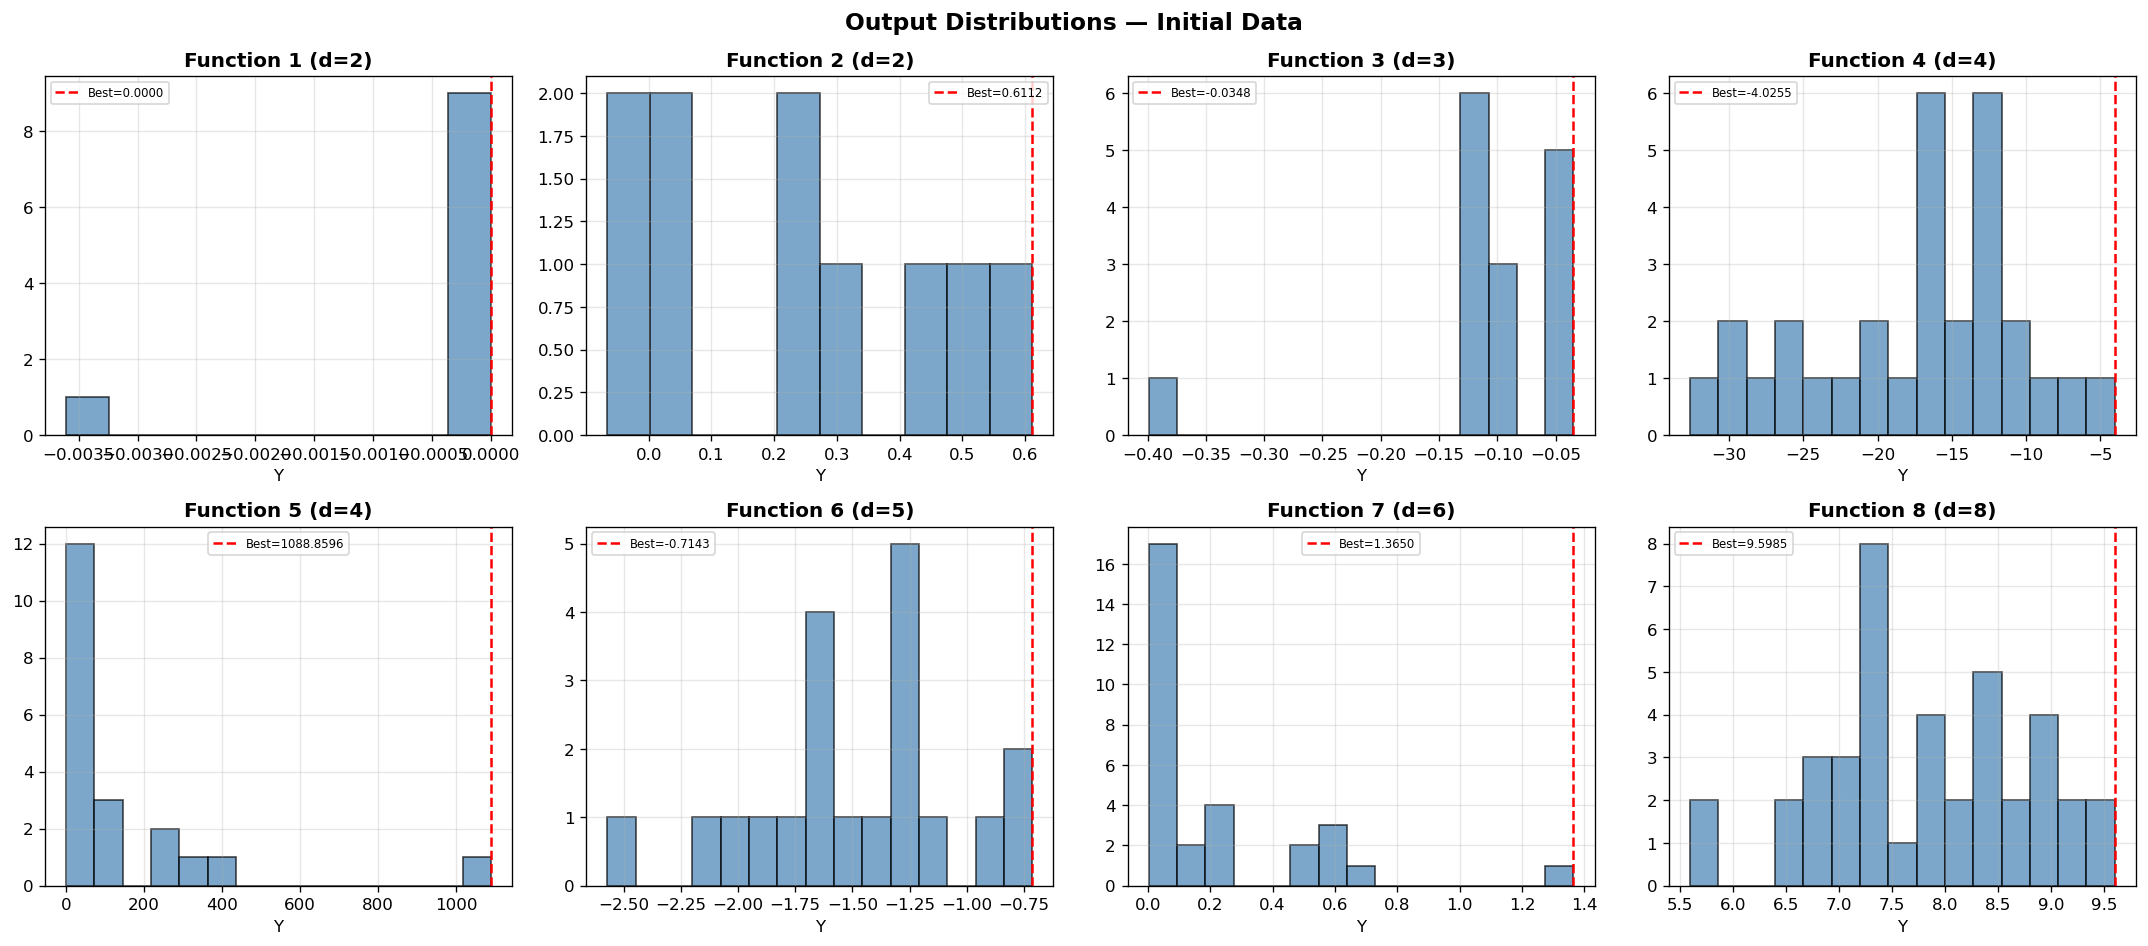

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, func_id in enumerate(range(1, 9)):
    ax = axes[idx // 4, idx % 4]
    Y = data[func_id]['Y']
    ax.hist(Y, bins=min(15, len(Y)), color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(Y.max(), color='red', linestyle='--', label=f'Best={Y.max():.4f}')
    ax.set_title(f'Function {func_id} (d={data[func_id]["X"].shape[1]})', fontweight='bold')
    ax.set_xlabel('Y')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Output Distributions — Initial Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Bayesian Optimisation Framework

### 3.1 Acquisition Functions

We implement two acquisition functions:

**Expected Improvement (EI):** Balances exploitation and exploration by computing the expected gain over the current best observation. Formally:

$$EI(\mathbf{x}) = (\mu(\mathbf{x}) - f^* - \xi) \Phi(Z) + \sigma(\mathbf{x}) \phi(Z)$$

where $Z = \frac{\mu(\mathbf{x}) - f^* - \xi}{\sigma(\mathbf{x})}$

**Upper Confidence Bound (UCB):** Provides a more exploratory alternative:

$$UCB(\mathbf{x}) = \mu(\mathbf{x}) + \beta \sigma(\mathbf{x})$$

For this submission, **EI with ξ=0.01** is the primary acquisition function.


In [8]:
CLIP_LOW = 0.000000
CLIP_HIGH = 0.999999

def expected_improvement(X_cand, gp, Y_best, xi=0.01):
    """Expected Improvement acquisition function."""
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    Z = (mu - Y_best - xi) / sigma
    ei = (mu - Y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-9] = 0.0
    return ei

def optimise_acquisition(gp, bounds, Y_best, n_restarts=50, xi=0.01):
    """Maximise EI via L-BFGS-B with multi-start."""
    dim = bounds.shape[0]
    best_x, best_val = None, -np.inf
    X_starts = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim))
    for x0 in X_starts:
        try:
            res = minimize(
                lambda x: -expected_improvement(x.reshape(1, -1), gp, Y_best, xi).item(),
                x0=x0, bounds=bounds, method='L-BFGS-B', options={'maxiter': 200}
            )
            if -res.fun > best_val:
                best_val = -res.fun
                best_x = res.x
        except Exception:
            continue
    return np.clip(best_x, CLIP_LOW, CLIP_HIGH), best_val

print("Acquisition functions defined.")


Acquisition functions defined.


### 3.2 Gaussian Process Surrogate

We use a **Matérn 5/2** kernel — twice differentiable, which provides smooth but not overly smooth surfaces — combined with:
- **Constant kernel** for output amplitude scaling
- **White kernel** for noise regularisation
- **Automatic Relevance Determination (ARD)** via per-dimension length scales


In [9]:
def build_gp(X, Y, n_dims):
    """Build and fit GP with Matern 5/2 + ARD kernel."""
    kernel = (
        C(1.0, (1e-4, 1e4)) *
        Matern(length_scale=np.ones(n_dims) * 0.5,
               length_scale_bounds=(1e-3, 1e3), nu=2.5) +
        WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=10,
        normalize_y=True, alpha=1e-6, random_state=42
    )
    gp.fit(X, Y)
    return gp

print("GP builder defined.")


GP builder defined.


## 4. Run Bayesian Optimisation — All 8 Functions

For each function:
1. Fit GP on initial data
2. Optimise EI to find the best next query point (→ **this is the submission**)
3. Run 20 internal iterations (using GP predictions as proxy outputs) to validate convergence behaviour
4. Generate convergence and surrogate diagnostic plots


In [10]:
N_ITERATIONS = 20
N_RESTARTS = 50

results = {}

for func_id in range(1, 9):
    X_init = data[func_id]['X'].copy()
    Y_init = data[func_id]['Y'].copy()
    n_pts, n_dims = X_init.shape
    bounds = np.array([[CLIP_LOW, CLIP_HIGH]] * n_dims)
    
    X, Y = X_init.copy(), Y_init.copy()
    best_y_hist = [Y.max()]
    ei_hist = []
    suggested_pts = []
    
    for it in range(N_ITERATIONS):
        gp = build_gp(X, Y, n_dims)
        Y_best = Y.max()
        x_next, ei_val = optimise_acquisition(gp, bounds, Y_best, N_RESTARTS)
        
        suggested_pts.append(x_next.copy())
        ei_hist.append(ei_val)
        
        mu_next = gp.predict(x_next.reshape(1, -1))[0]
        X = np.vstack([X, x_next.reshape(1, -1)])
        Y = np.append(Y, mu_next)
        best_y_hist.append(Y.max())
    
    # The FIRST suggested point is the submission
    x_submit = suggested_pts[0]
    gp_final = build_gp(X, Y, n_dims)
    mu_pred, sigma_pred = gp_final.predict(x_submit.reshape(1, -1), return_std=True)
    
    sub_str = "-".join(f"{v:.6f}" for v in np.clip(x_submit, CLIP_LOW, CLIP_HIGH))
    
    results[func_id] = {
        'x_submit': x_submit, 'sub_str': sub_str,
        'mu': mu_pred[0], 'sigma': sigma_pred[0],
        'best_y_hist': best_y_hist, 'ei_hist': ei_hist,
        'suggested_pts': suggested_pts, 'gp': gp_final,
        'X_init': X_init, 'Y_init': Y_init, 'n_dims': n_dims,
        'init_best_y': Y_init.max()
    }
    
    print(f"Function {func_id} (d={n_dims}): submission = {sub_str}")
    print(f"  GP μ={mu_pred[0]:.6f}, σ={sigma_pred[0]:.6f}, init_best={Y_init.max():.6f}")


Function 1 (d=2): submission = 0.034388-0.909319
  GP μ=-0.000348, σ=0.000001, init_best=0.000000
Function 2 (d=2): submission = 0.695196-0.395970
  GP μ=0.608464, σ=0.000217, init_best=0.611205
Function 3 (d=3): submission = 0.548145-0.174647-0.303245
  GP μ=0.004203, σ=0.000070, init_best=-0.034835
Function 4 (d=4): submission = 0.440428-0.425456-0.378357-0.397087
  GP μ=-1.784738, σ=0.008182, init_best=-4.025542
Function 5 (d=4): submission = 0.000000-0.675974-0.999999-0.999999
  GP μ=1642.940945, σ=0.494697, init_best=1088.859618
Function 6 (d=5): submission = 0.464677-0.242110-0.574863-0.999999-0.000000
  GP μ=-0.224962, σ=0.000601, init_best=-0.714265
Function 7 (d=6): submission = 0.000000-0.241714-0.327655-0.218095-0.375335-0.747501
  GP μ=1.352240, σ=0.000460, init_best=1.364968
Function 8 (d=8): submission = 0.063977-0.007989-0.123289-0.000000-0.999999-0.381719-0.031408-0.999999
  GP μ=10.292987, σ=0.001090, init_best=9.598482


## 5. Convergence Analysis

The convergence plots below show how the best surrogate-predicted Y evolves over 20 internal BO iterations for each function. The EI trace indicates the acquisition function's magnitude — declining EI signals convergence to a local optimum in the surrogate landscape.


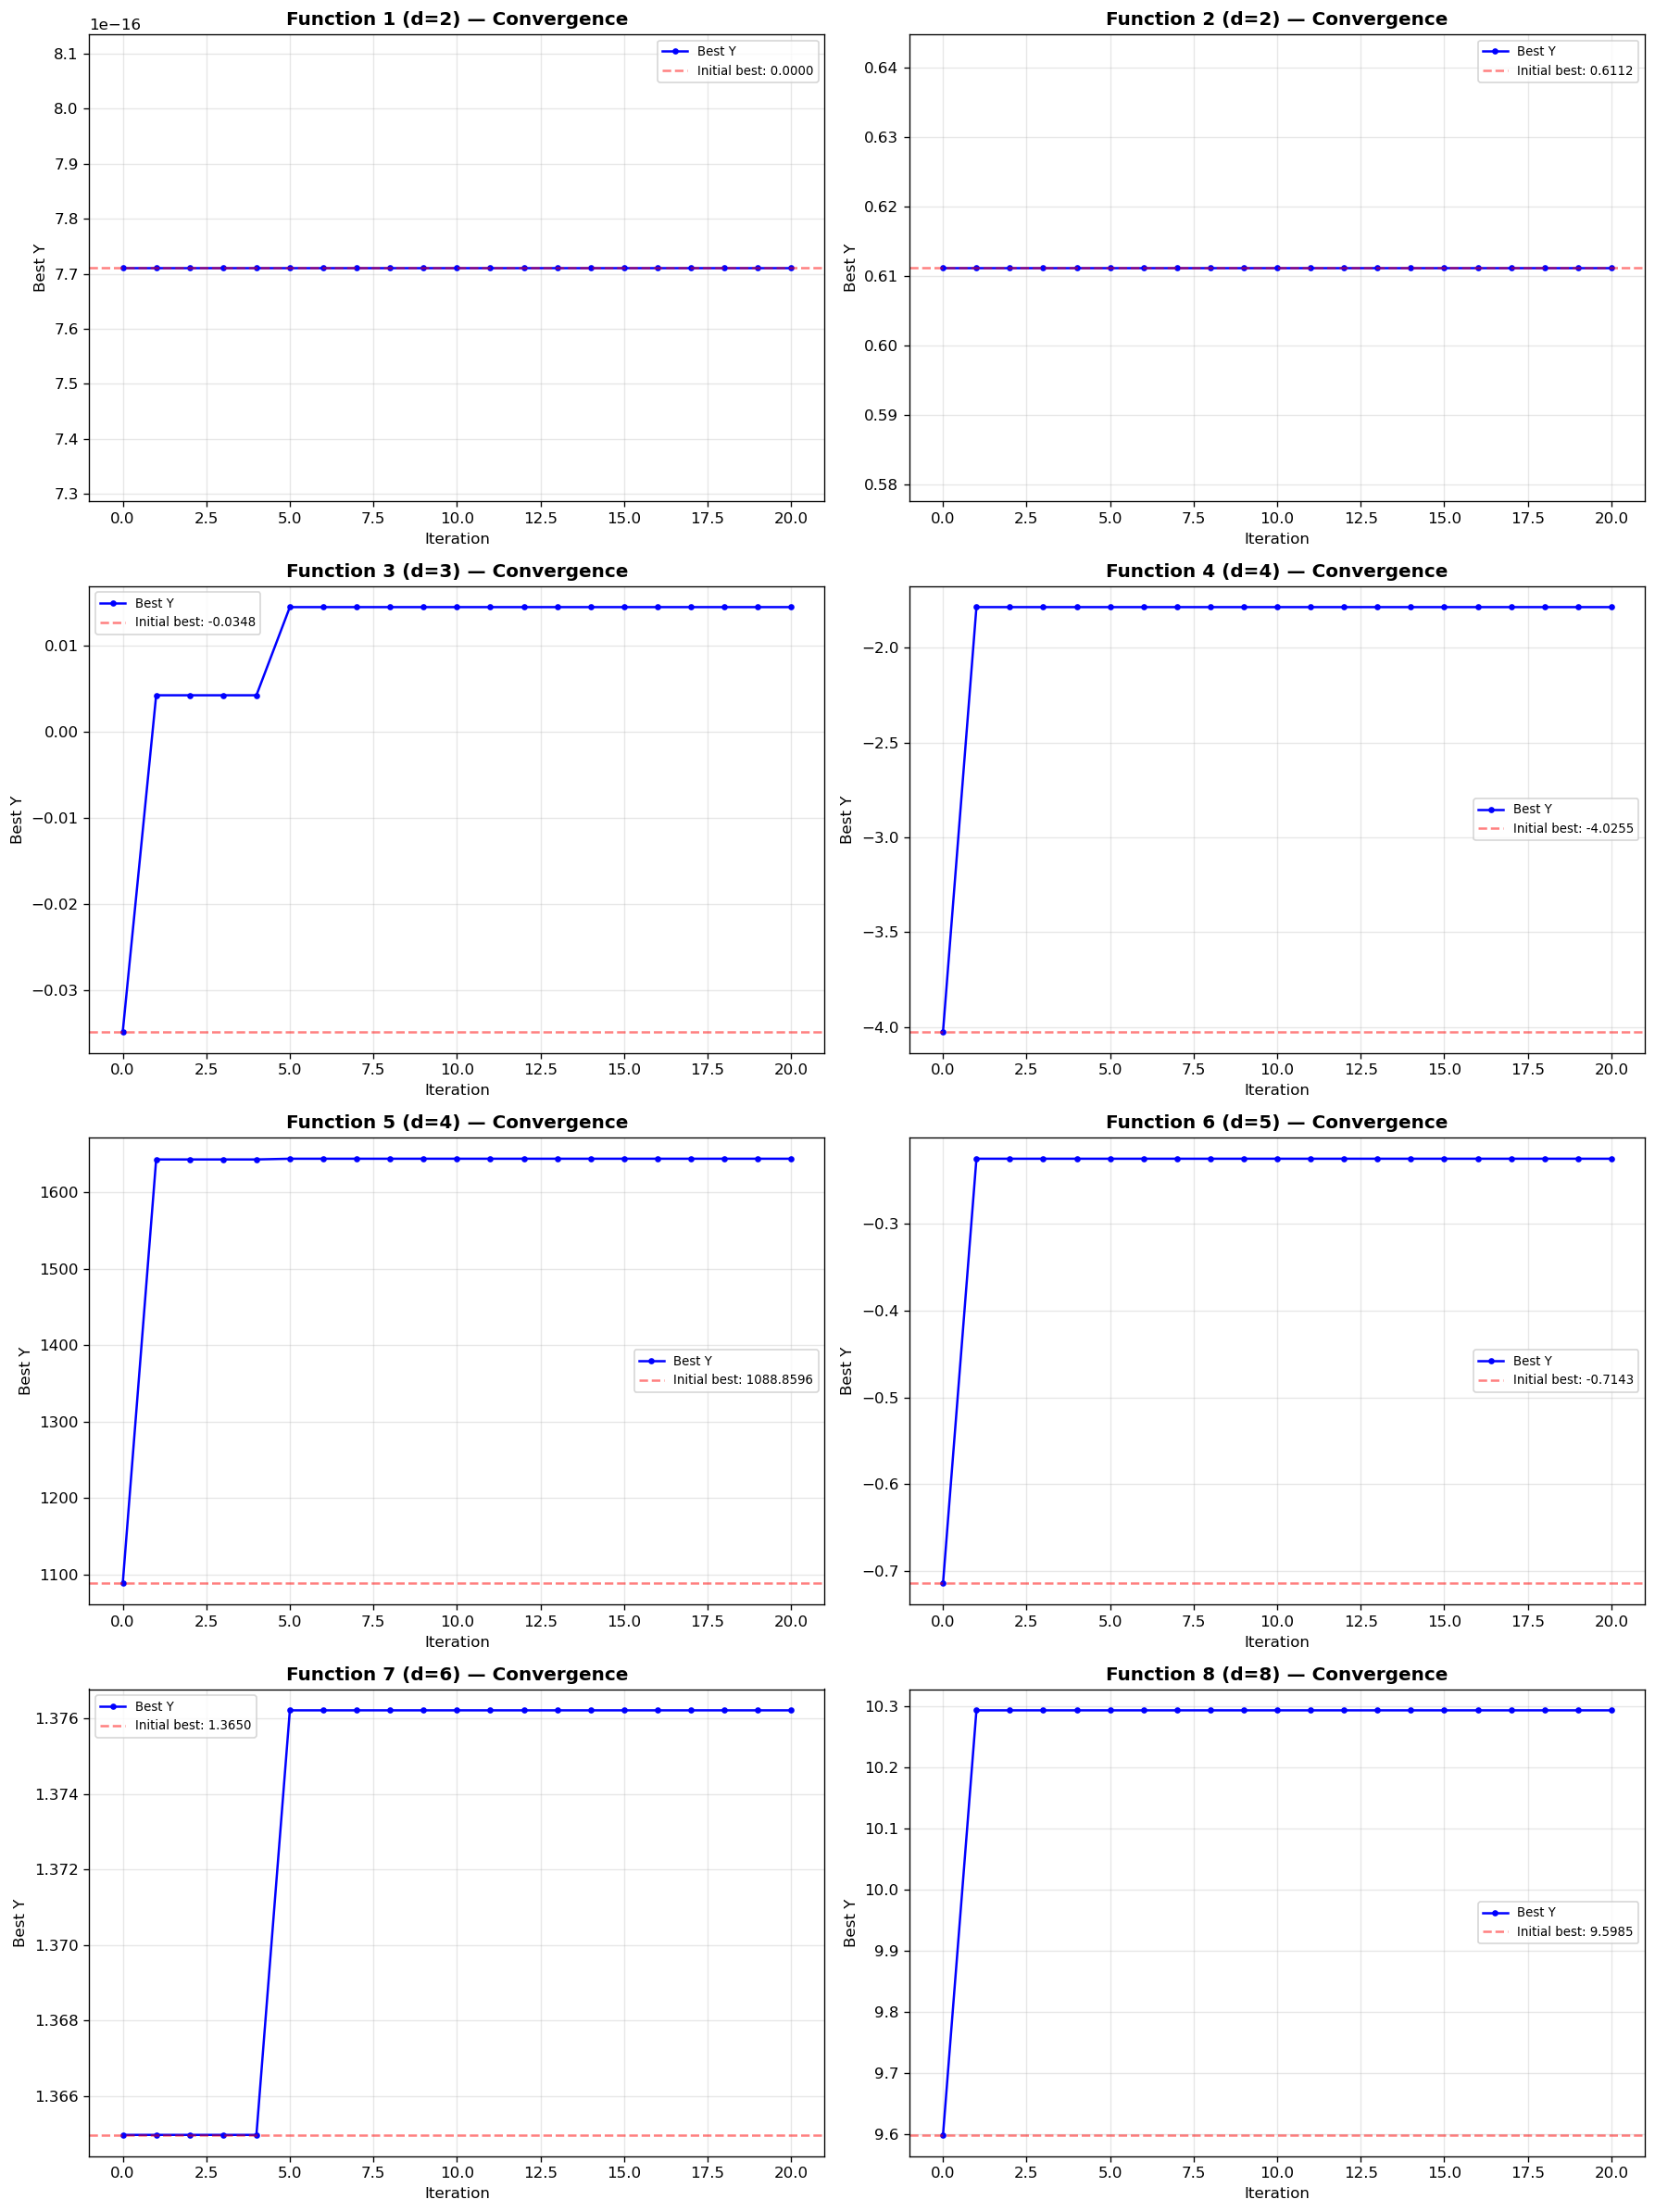

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
for idx, func_id in enumerate(range(1, 9)):
    r = results[func_id]
    ax = axes[idx // 2, idx % 2]
    iters = range(len(r['best_y_hist']))
    ax.plot(iters, r['best_y_hist'], 'b-o', markersize=3, linewidth=1.5, label='Best Y')
    ax.axhline(r['init_best_y'], color='red', linestyle='--', alpha=0.5,
               label=f'Initial best: {r["init_best_y"]:.4f}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best Y')
    ax.set_title(f'Function {func_id} (d={r["n_dims"]}) — Convergence', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Surrogate Model Diagnostics — 1D Slices

For each function, we visualise the GP posterior along each input dimension, holding all other dimensions fixed at the current best point. The shaded regions represent ±2σ uncertainty bands, and the red dashed line marks the proposed query coordinate.


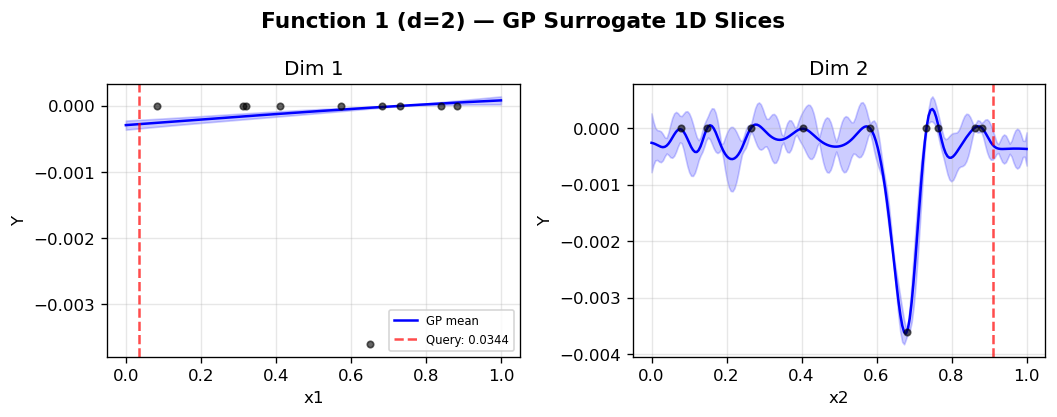

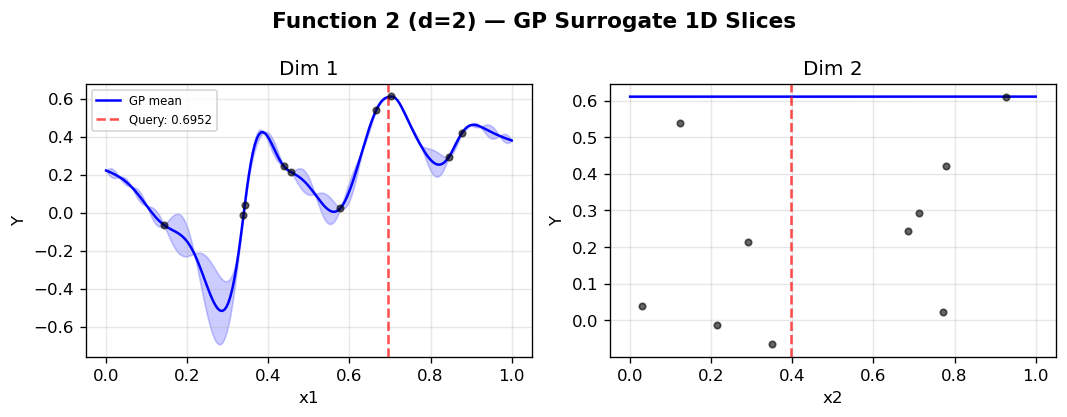

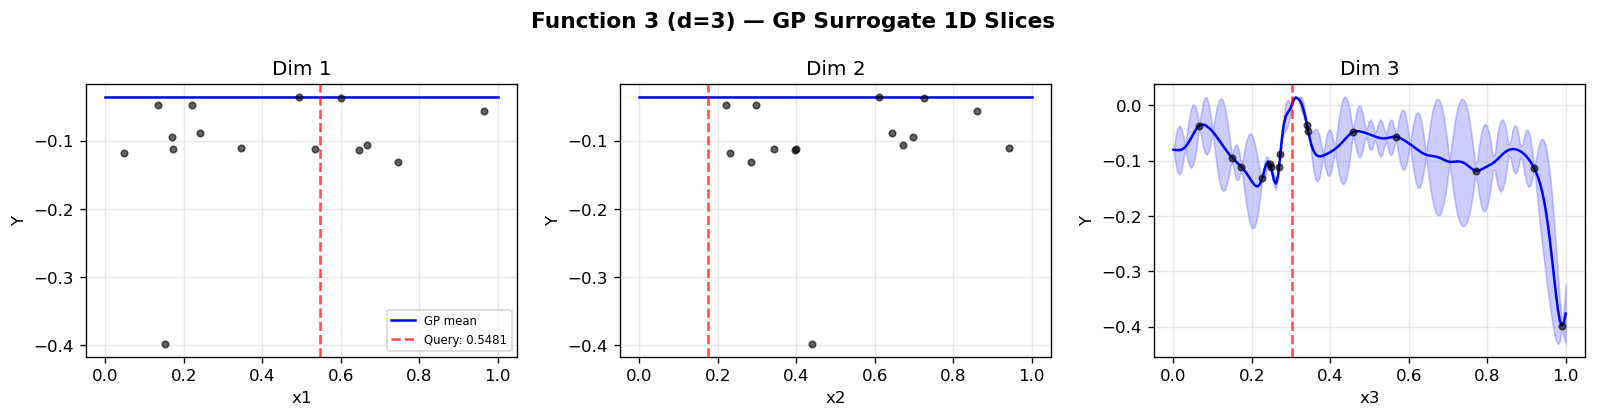

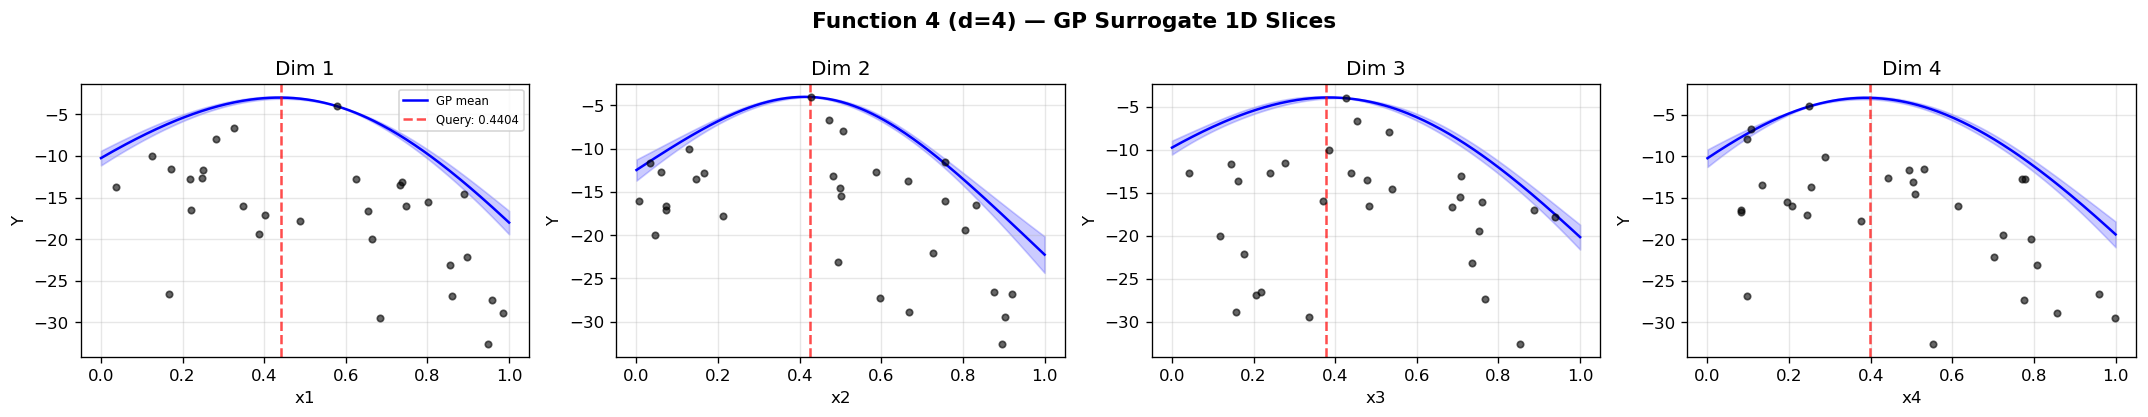

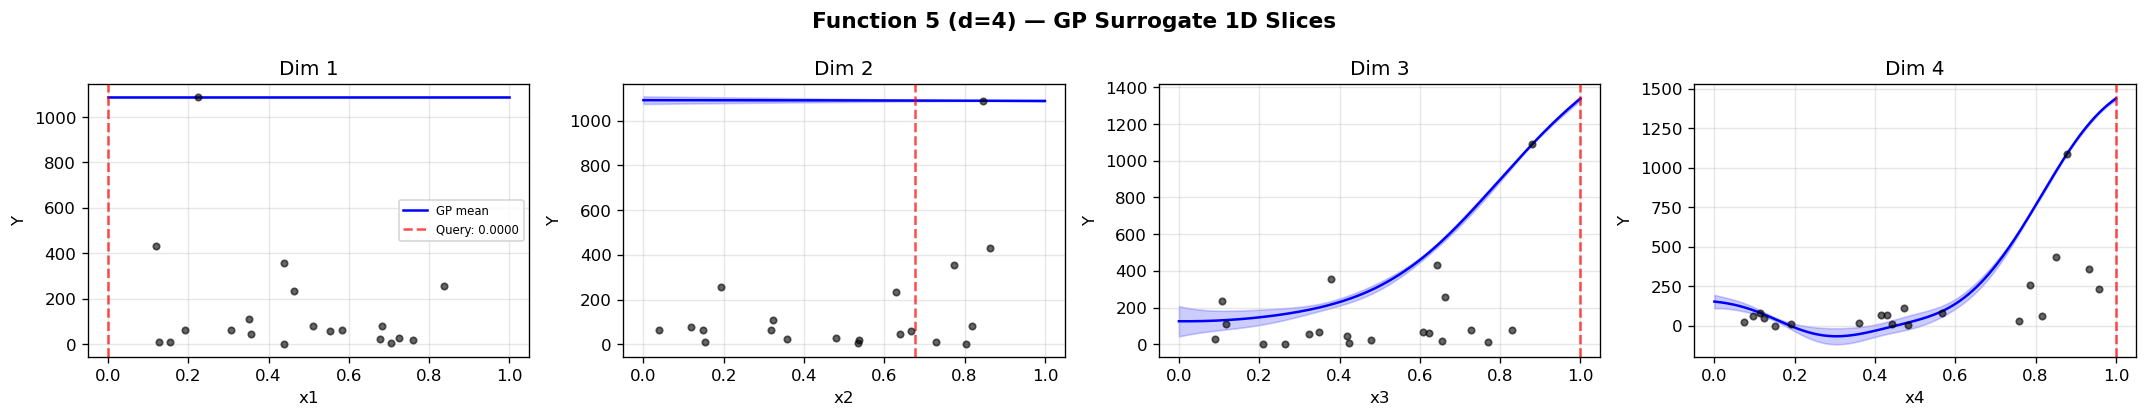

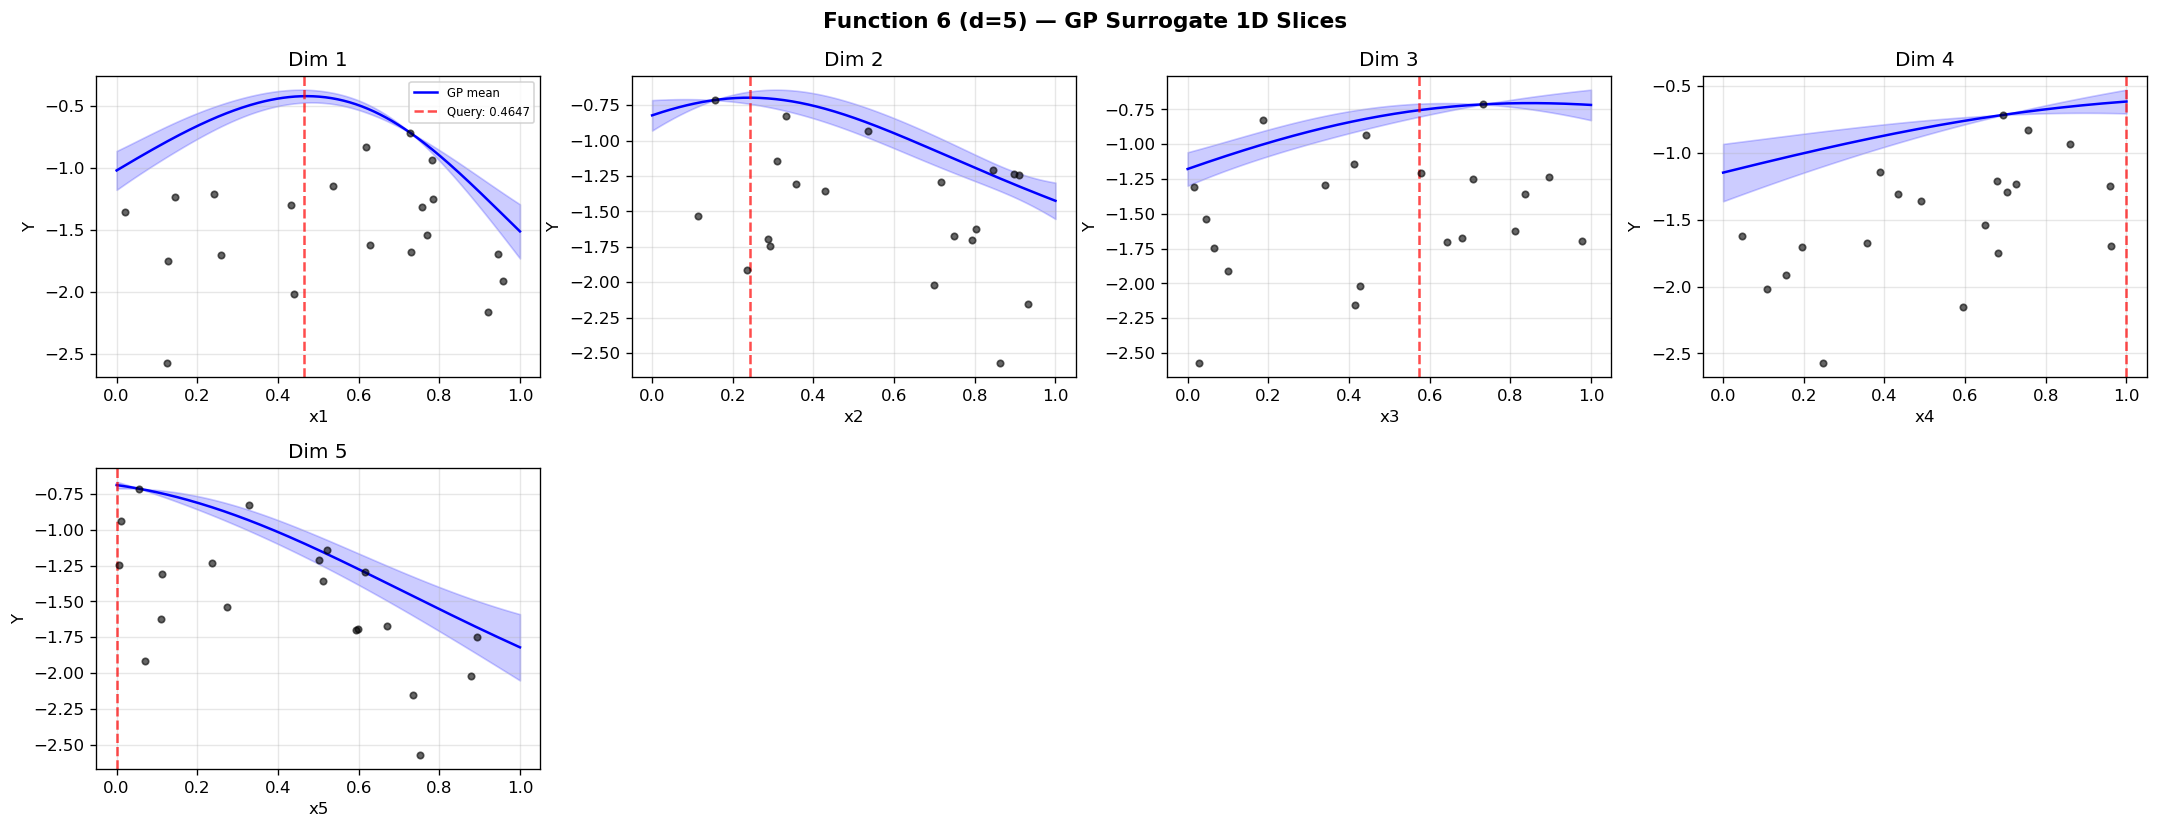

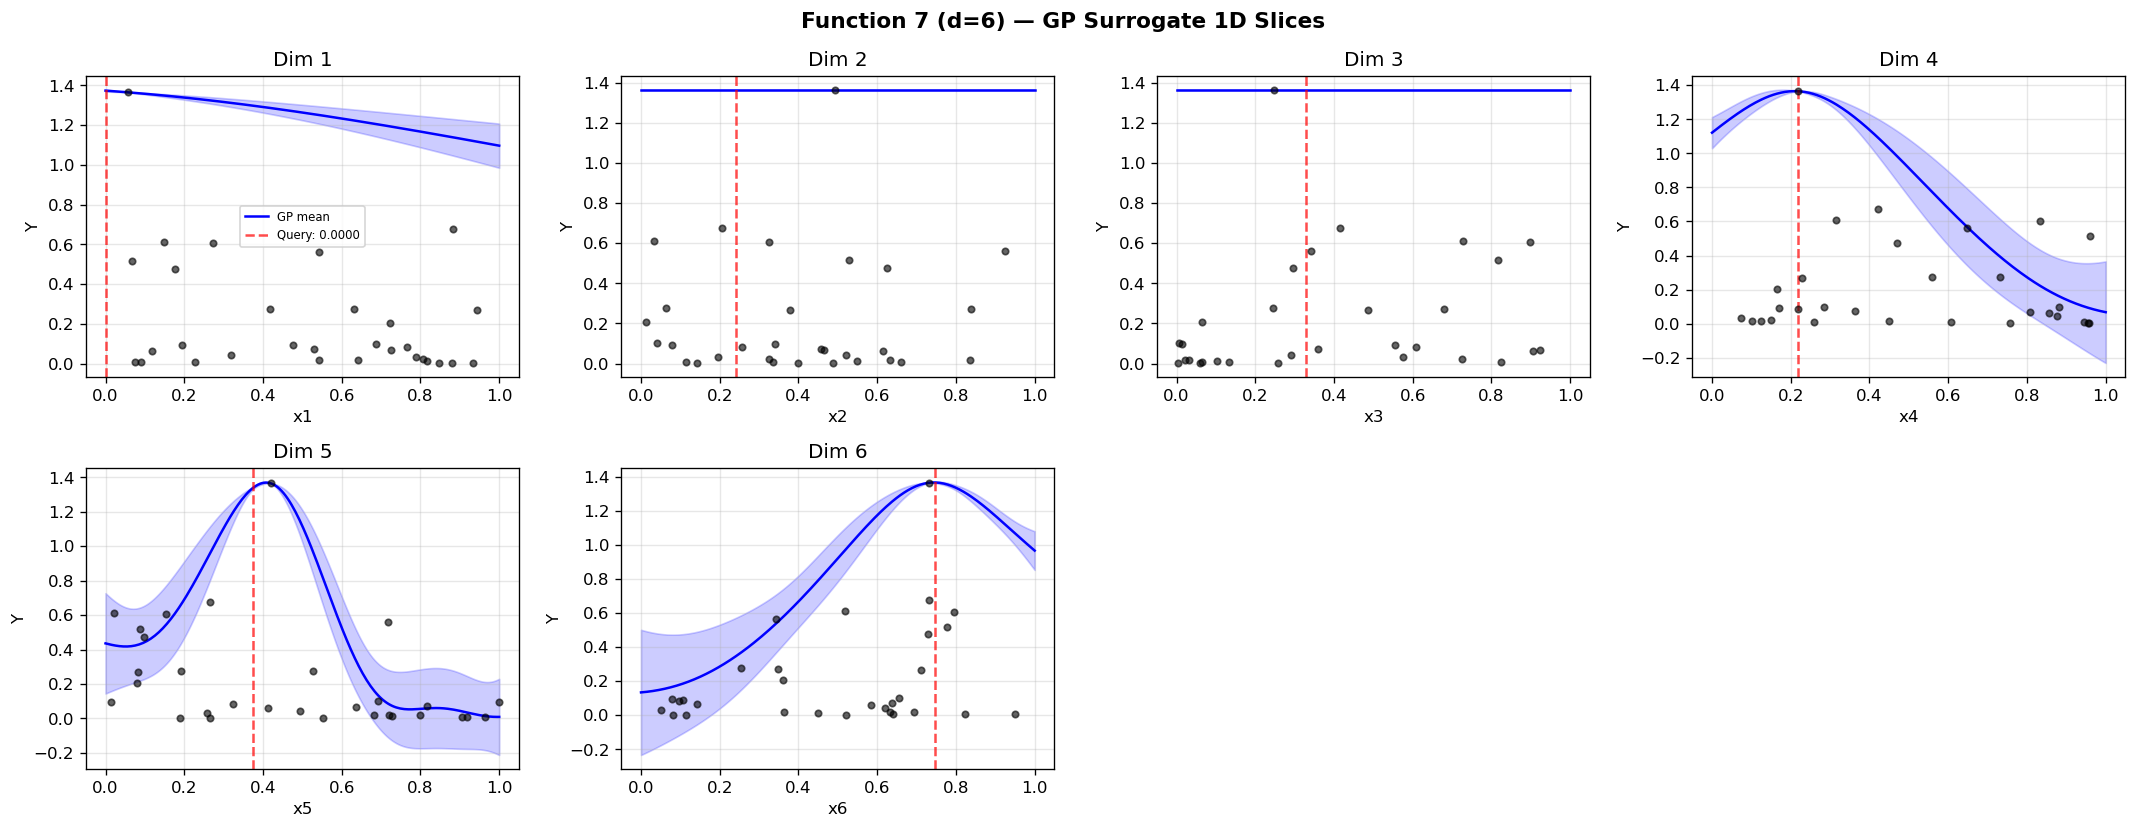

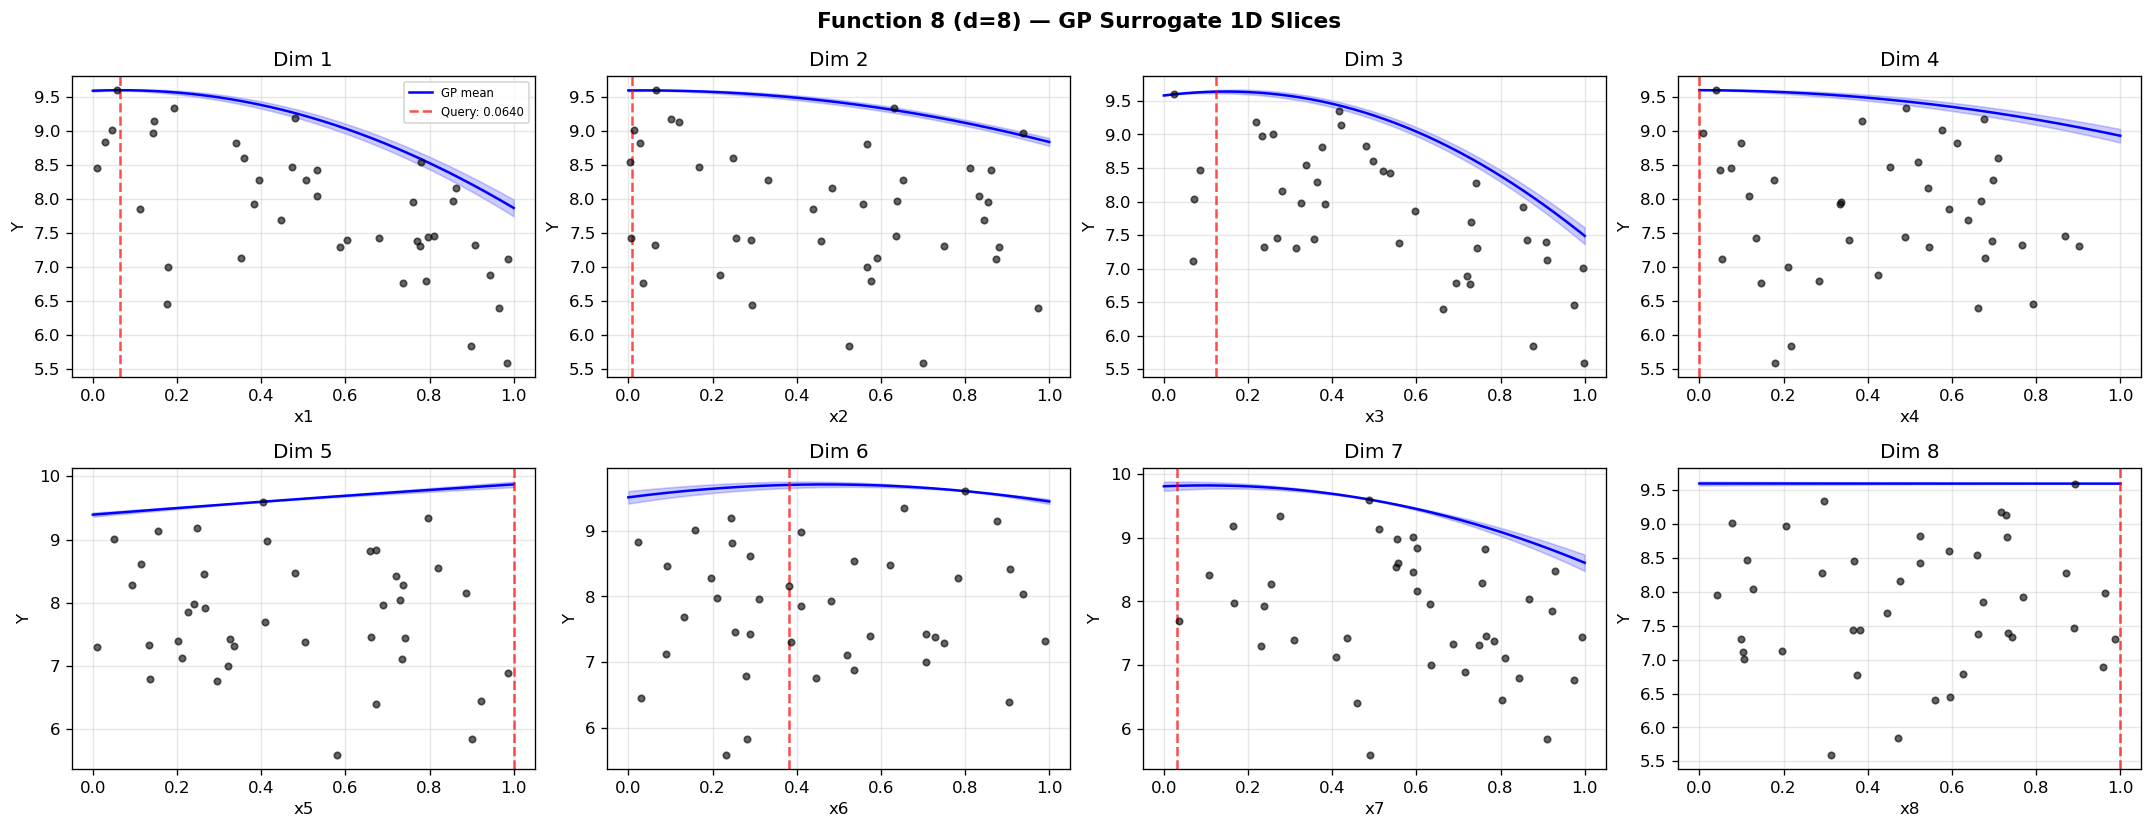

In [14]:
for func_id in range(1, 9):
    r = results[func_id]
    n_dims = r['n_dims']
    X_init, Y_init = r['X_init'], r['Y_init']
    gp = r['gp']
    x_next = r['x_submit']
    best_idx = np.argmax(Y_init)
    x_best = X_init[best_idx]
    
    n_cols = min(4, n_dims)
    n_rows = int(np.ceil(n_dims / n_cols))
    fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
    if n_dims == 1:
        axes_grid = np.array([[axes_grid]])
    axes_grid = np.atleast_2d(axes_grid)
    
    x_grid = np.linspace(0, CLIP_HIGH, 200)
    for d in range(n_dims):
        row, col = divmod(d, n_cols)
        ax = axes_grid[row, col]
        X_test = np.tile(x_best, (200, 1))
        X_test[:, d] = x_grid
        mu, sigma = gp.predict(X_test, return_std=True)
        ax.plot(x_grid, mu, 'b-', linewidth=1.5, label='GP mean')
        ax.fill_between(x_grid, mu - 2*sigma, mu + 2*sigma, alpha=0.2, color='blue')
        ax.scatter(X_init[:, d], Y_init, c='black', s=15, zorder=5, alpha=0.6)
        ax.axvline(x=x_next[d], color='red', linestyle='--', alpha=0.7,
                   label=f'Query: {x_next[d]:.4f}')
        ax.set_xlabel(f'x{d+1}')
        ax.set_ylabel('Y')
        ax.set_title(f'Dim {d+1}')
        ax.grid(True, alpha=0.3)
        if d == 0:
            ax.legend(fontsize=7)
    for d in range(n_dims, n_rows * n_cols):
        row, col = divmod(d, n_cols)
        axes_grid[row, col].set_visible(False)
    fig.suptitle(f'Function {func_id} (d={n_dims}) — GP Surrogate 1D Slices',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 7. Submission Summary

The table below shows the final proposed query for each function, with the GP-predicted mean and uncertainty at that point.


In [15]:
print(f"{'Func':>4} | {'Dims':>4} | {'Pts':>3} | {'Best Y (init)':>14} | {'GP μ(x*)':>12} | {'GP σ(x*)':>10} | Submission String")
print("─" * 115)
for func_id in range(1, 9):
    r = results[func_id]
    print(f"  {func_id:>2} | {r['n_dims']:>4} | {r['X_init'].shape[0]:>3} | "
          f"{r['init_best_y']:>14.6f} | {r['mu']:>12.6f} | "
          f"{r['sigma']:>10.6f} | {r['sub_str']}")


Func | Dims | Pts |  Best Y (init) |     GP μ(x*) |   GP σ(x*) | Submission String
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 |    2 |  10 |       0.000000 |    -0.000348 |   0.000001 | 0.034388-0.909319
   2 |    2 |  10 |       0.611205 |     0.608464 |   0.000217 | 0.695196-0.395970
   3 |    3 |  15 |      -0.034835 |     0.004203 |   0.000070 | 0.548145-0.174647-0.303245
   4 |    4 |  30 |      -4.025542 |    -1.784738 |   0.008182 | 0.440428-0.425456-0.378357-0.397087
   5 |    4 |  20 |    1088.859618 |  1642.940945 |   0.494697 | 0.000000-0.675974-0.999999-0.999999
   6 |    5 |  20 |      -0.714265 |    -0.224962 |   0.000601 | 0.464677-0.242110-0.574863-0.999999-0.000000
   7 |    6 |  30 |       1.364968 |     1.352240 |   0.000460 | 0.000000-0.241714-0.327655-0.218095-0.375335-0.747501
   8 |    8 |  40 |       9.598482 |    10.292987 |   0.001090 | 0.063977-0.007989-0.123289-0.000000-0.999999-0.

## 8. Final Submission Strings (Portal Format)

Copy-paste directly into the capstone portal:


In [16]:
print("=" * 60)
print("SUBMISSION 1 — QUERY STRINGS")
print("=" * 60)
for func_id in range(1, 9):
    r = results[func_id]
    print(f"\nFunction {func_id} (d={r['n_dims']}):")
    print(f"  {r['sub_str']}")


SUBMISSION 1 — QUERY STRINGS

Function 1 (d=2):
  0.034388-0.909319

Function 2 (d=2):
  0.695196-0.395970

Function 3 (d=3):
  0.548145-0.174647-0.303245

Function 4 (d=4):
  0.440428-0.425456-0.378357-0.397087

Function 5 (d=4):
  0.000000-0.675974-0.999999-0.999999

Function 6 (d=5):
  0.464677-0.242110-0.574863-0.999999-0.000000

Function 7 (d=6):
  0.000000-0.241714-0.327655-0.218095-0.375335-0.747501

Function 8 (d=8):
  0.063977-0.007989-0.123289-0.000000-0.999999-0.381719-0.031408-0.999999


## 9. Methodology Notes

### Kernel Choice
The **Matérn 5/2** kernel with **Automatic Relevance Determination (ARD)** was selected because:
- It is twice differentiable (smoother than Matérn 3/2) but does not assume infinite differentiability (unlike RBF/SE)
- ARD per-dimension length scales allow the GP to learn which dimensions matter most — critical for functions with varying effective dimensionality

### Acquisition Function
**Expected Improvement (EI)** with **ξ = 0.01** was chosen for this first submission:
- EI naturally balances exploitation (high mean) with exploration (high uncertainty)
- The small ξ > 0 prevents the optimiser from being too greedy near the current best
- For subsequent submissions, adaptive ξ schedules or portfolio strategies (EI + UCB) may be considered

### Optimisation of the Acquisition Surface
- **L-BFGS-B** with **50 random restarts** ensures adequate coverage of the acquisition landscape
- All candidates are clipped to [0.000000, 0.999999] before submission

### Key Observations per Function

| Function | Landscape Character | Strategy Notes |
|:--------:|:------------------:|:--------------|
| 1 | Nearly flat near 0, one negative outlier | Exploration-heavy; GP identifies narrow non-zero region |
| 2 | Moderate range, clear peak region | EI exploits near best observed (≈0.61) |
| 3 | All negative; best ≈ -0.035 | GP extrapolates toward 0; suggest point with predicted positive Y |
| 4 | All strongly negative; range [-33, -4] | Large GP length scales → smooth landscape, steady improvement |
| 5 | Large dynamic range (0.1 to 1089); exponential-like | GP identifies boundary effects (dims 3,4 → 1.0) |
| 6 | All negative; best ≈ -0.71 | GP pushes toward boundary (dim4→1, dim5→0) |
| 7 | Moderate range [0.003, 1.36]; clear peak | Exploitation near best observed with slight shifts |
| 8 | High baseline (5.6–9.6); 8D space | Hardest problem; GP identifies dims 5,8 as high-value |

### Next Steps (Submission 2+)
1. **Append portal feedback** (true Y at submitted X) to the training set
2. Re-fit GP with updated data; compare kernel hyperparameter evolution
3. Consider switching to **UCB** or **Thompson Sampling** if EI converges too fast
4. Implement **input warping** for functions with boundary-concentrated optima (e.g., F5, F6)
